In [1]:
import pandas as pd
# dados normalizados sem outliers
df = pd.read_parquet("../df_normal.parquet")


### Regressão Ridge

In [2]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_ridge = df.copy()

X_ridge = df_ridge.drop(columns=["exam_score"], errors="ignore")
y_ridge = df_ridge["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo Ridge Regression
modelo_ridge = Ridge(
    alpha=1.0,
    random_state=42
)

# Validação cruzada
resultados_ridge = cross_validate(
    modelo_ridge,
    X_ridge,
    y_ridge,
    cv=kfold,
    scoring=[
        "r2",
        "explained_variance",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
        "neg_median_absolute_error",
        "max_error"
    ],
    n_jobs=-1,
    return_train_score=True
)
# Resultados por fold
print("R2 por fold:", resultados_ridge["test_r2"])

# Médias das métricas
print("R2 médio:", resultados_ridge["test_r2"].mean())

print("Explained Variance média:",
      resultados_ridge["test_explained_variance"].mean())

print("MAE médio:",
      -resultados_ridge["test_neg_mean_absolute_error"].mean())

print("MSE médio:",
      -resultados_ridge["test_neg_mean_squared_error"].mean())

print("RMSE médio:",
      -resultados_ridge["test_neg_root_mean_squared_error"].mean())

print("Median Absolute Error médio:",
      -resultados_ridge["test_neg_median_absolute_error"].mean())

print("Max Error médio:",
      resultados_ridge["test_max_error"].mean())

R2 por fold: [0.80435161 0.80405061 0.80282318 0.80487595 0.80598768]
R2 médio: 0.804417806263307
Explained Variance média: 0.804418306489343
MAE médio: 0.35716486166006317
MSE médio: 0.1955774416053509
RMSE médio: 0.4422409702517949
Median Absolute Error médio: 0.3085565693493882
Max Error médio: -1.859150326453069


Análise dos resíduos

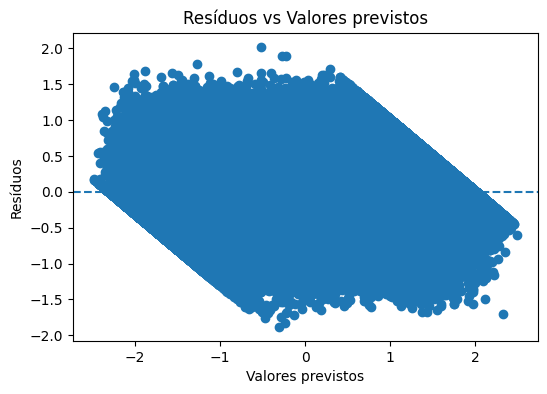

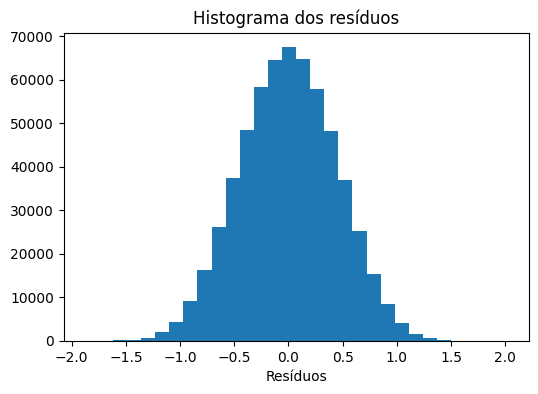

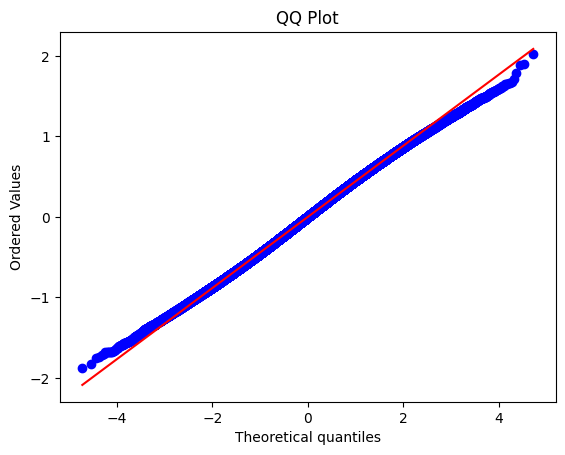

C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 598500.
  res = hypotest_fun_out(*samples, **kwds)



--- Normalidade ---
p-value Shapiro: 1.4244445248001248e-32
Resíduos NÃO normais

--- Homocedasticidade ---
p-value Breusch-Pagan: 7.772766788265573e-259
Possível heterocedasticidade

--- Independência dos erros ---
Durbin-Watson: 2.0033107019716603
Sem autocorrelação relevante


C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- VIF ---
                        Variável           VIF
0                    study_hours           inf
1                internet_access  1.000839e+00
2                    sleep_hours  4.846406e+00
3           sleep_quality_mapped  1.748741e+01
4         facility_rating_mapped  1.002956e+00
5         exam_difficulty_mapped  3.886619e+00
6       study_method_group study  1.576351e+00
7             study_method_mixed  1.574666e+00
8     study_method_online videos  1.565696e+00
9        study_method_self-study  1.598541e+00
10                   course_b.sc  1.649509e+00
11                 course_b.tech  1.729023e+00
12                     course_ba  1.403863e+00
13                    course_bba  1.477599e+00
14                    course_bca  1.543838e+00
15                course_diploma  1.333132e+00
16                   gender_male  1.340492e+00
17                  gender_other  1.340497e+00
18              total_study_time  2.583318e+08
19                 sleep_balance  2.087861e+10


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================================================
# AJUSTAR O MODELO RIDGE QUE JÁ TENS
# =========================================================

modelo_ridge.fit(X_ridge, y_ridge)

# Previsões
y_pred = modelo_ridge.predict(X_ridge)

# Resíduos
residuos = y_ridge - y_pred

# =========================================================
# 1. LINEARIDADE
# =========================================================

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores previstos")
plt.show()

# =========================================================
# 2. NORMALIDADE DOS RESÍDUOS
# =========================================================

# Histograma
plt.figure(figsize=(6,4))
plt.hist(residuos, bins=30)
plt.title("Histograma dos resíduos")
plt.xlabel("Resíduos")
plt.show()

# QQ Plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

# Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)

print("\n--- Normalidade ---")
print("p-value Shapiro:", shapiro_p)

if shapiro_p > 0.05:
    print("Resíduos aproximadamente normais")
else:
    print("Resíduos NÃO normais")

# =========================================================
# 3. HOMOCEDASTICIDADE
# =========================================================

X_const = sm.add_constant(X_ridge)

bp_test = het_breuschpagan(residuos, X_const)

print("\n--- Homocedasticidade ---")
print("p-value Breusch-Pagan:", bp_test[1])

if bp_test[1] > 0.05:
    print("Homocedasticidade verificada")
else:
    print("Possível heterocedasticidade")

# =========================================================
# 4. INDEPENDÊNCIA DOS ERROS
# =========================================================

dw = durbin_watson(residuos)

print("\n--- Independência dos erros ---")
print("Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Sem autocorrelação relevante")
else:
    print("Possível autocorrelação")

# =========================================================
# 5. MULTICOLINEARIDADE
# =========================================================

vif_df = pd.DataFrame()
vif_df["Variável"] = X_ridge.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_ridge.values, i)
    for i in range(X_ridge.shape[1])
]

print("\n--- VIF ---")
print(vif_df)

print("\nInterpretação:")
print("VIF < 5  -> OK")
print("VIF 5-10 -> Moderado")
print("VIF > 10 -> Multicolinearidade forte")

Novo Ridge

In [4]:
# =========================================================
# REMOVER VARIÁVEIS COM MULTICOLINEARIDADE ELEVADA
# =========================================================

X_ridge_reduzido = X_ridge.drop(columns=[
    "total_study_time",
    "sleep_balance",
    "study_sleep_ratio",
    "log_study_hours"
])

# =========================================================
# RECALCULAR VIF
# =========================================================

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_resultados = pd.DataFrame()

vif_resultados["feature"] = X_ridge_reduzido.columns

vif_resultados["VIF"] = [
    variance_inflation_factor(X_ridge_reduzido.values, indice)
    for indice in range(X_ridge_reduzido.shape[1])
]

# Mostrar resultados
print(vif_resultados.sort_values(by="VIF", ascending=False))

C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         feature           VIF
0                    study_hours           inf
19  study_attendance_interaction           inf
23                  study_effort           inf
18           study_hours_squared           inf
24                  rest_balance  4.731293e+10
20          sleep_quality_effect  1.657150e+09
21                study_vs_sleep  2.047570e+01
3           sleep_quality_mapped  1.748729e+01
25              study_difficulty  5.799875e+00
2                    sleep_hours  4.842163e+00
5         exam_difficulty_mapped  3.886537e+00
22           attendance_residual  3.884526e+00
11                 course_b.tech  1.728122e+00
10                   course_b.sc  1.649290e+00
9        study_method_self-study  1.598411e+00
6       study_method_group study  1.576287e+00
7             study_method_mixed  1.574097e+00
8     study_method_online videos  1.565625e+00
14                    course_bca  1.543821e+00
13                    course_bba  1.477578e+00
12           

In [5]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, KFold

# =========================================================
# NOVO X (APÓS REMOÇÃO DE MULTICOLINEARIDADE)
# =========================================================

X_ridge_reduzido = X_ridge.drop(columns=[
    "total_study_time",
    "sleep_balance",
    "study_sleep_ratio",
    "log_study_hours"
])

# =========================================================
# MODELO RIDGE (COM SCALING)
# =========================================================

modelo_ridge_novo = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# =========================================================
# CROSS-VALIDATION
# =========================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_ridge_novo = cross_validate(
    modelo_ridge_novo,
    X_ridge_reduzido,
    y_ridge,
    cv=kfold,
    scoring=[
        "r2",
        "explained_variance",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
        "neg_median_absolute_error",
        "max_error"
    ],
    n_jobs=-1,
    return_train_score=True
)

# =========================================================
# RESULTADOS
# =========================================================

print("R2 por fold:", resultados_ridge_novo["test_r2"])
print("R2 médio:", resultados_ridge_novo["test_r2"].mean())

print("Explained Variance médio:",
      resultados_ridge_novo["test_explained_variance"].mean())

print("MAE médio:",
      -resultados_ridge_novo["test_neg_mean_absolute_error"].mean())

print("MSE médio:",
      -resultados_ridge_novo["test_neg_mean_squared_error"].mean())

print("RMSE médio:",
      -resultados_ridge_novo["test_neg_root_mean_squared_error"].mean())

print("Median AE médio:",
      -resultados_ridge_novo["test_neg_median_absolute_error"].mean())

print("Max Error médio:",
      resultados_ridge_novo["test_max_error"].mean())

R2 por fold: [0.80427305 0.8040124  0.80271854 0.80478705 0.80591591]
R2 médio: 0.8043413899253979
Explained Variance médio: 0.8043419336232688
MAE médio: 0.35717873879121953
MSE médio: 0.19565382168328962
RMSE médio: 0.4423273186088491
Median AE médio: 0.30850100922161566
Max Error médio: -1.858782779706774
